In [14]:
# %% [markdown]
# # Session Data Exploration
# Loads all 4 sessions and produces:
# - Correct / Wrong / Miss bar graph per session
# - All trial pathways per session
# - RT and accuracy plots per session

In [23]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import sys

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from scripts.utils import flag_overtakes, get_target_side

In [16]:
# %%
# ── Define session files ───────────────────────────────────────
SESSION_FILES = {
    "Session 1 (June15)" : r"C:\Users\menonm\Documents\Marieke_Overtake\Files&Figures\June15\test01_June15.pkl",
    "Session 2 (May18-1)": r"C:\Users\menonm\Documents\Marieke_Overtake\Files&Figures\May18\test01_May18.pkl",
    "Session 3 (May18-2)": r"C:\Users\menonm\Documents\Marieke_Overtake\Files&Figures\May18\test02_May18.pkl",
    "Session 4 (June2)"  : r"C:\Users\menonm\Documents\Marieke_Overtake\Files&Figures\June2\test01_June2.pkl",
}

In [22]:
print(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))

c:\Users\menonm\Documents\Marieke_Overtake


In [17]:
# %%
# ── Load all sessions ──────────────────────────────────────────
sessions = {}
for name, path in SESSION_FILES.items():
    with open(path, "rb") as f:
        data = pickle.load(f)
    data = flag_overtakes(data)
    if "TrialIndex" not in data.columns:
        data["TrialIndex"] = range(len(data))
    sessions[name] = data
    print(f"Loaded {name}: {len(data)} trials")

Loaded Session 1 (June15): 400 trials
Loaded Session 2 (May18-1): 185 trials
Loaded Session 3 (May18-2): 200 trials
Loaded Session 4 (June2): 328 trials


C:\Users\menonm\AppData\Local\Temp\ipykernel_20624\2902791992.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)
C:\Users\menonm\AppData\Local\Temp\ipykernel_20624\2902791992.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access fun

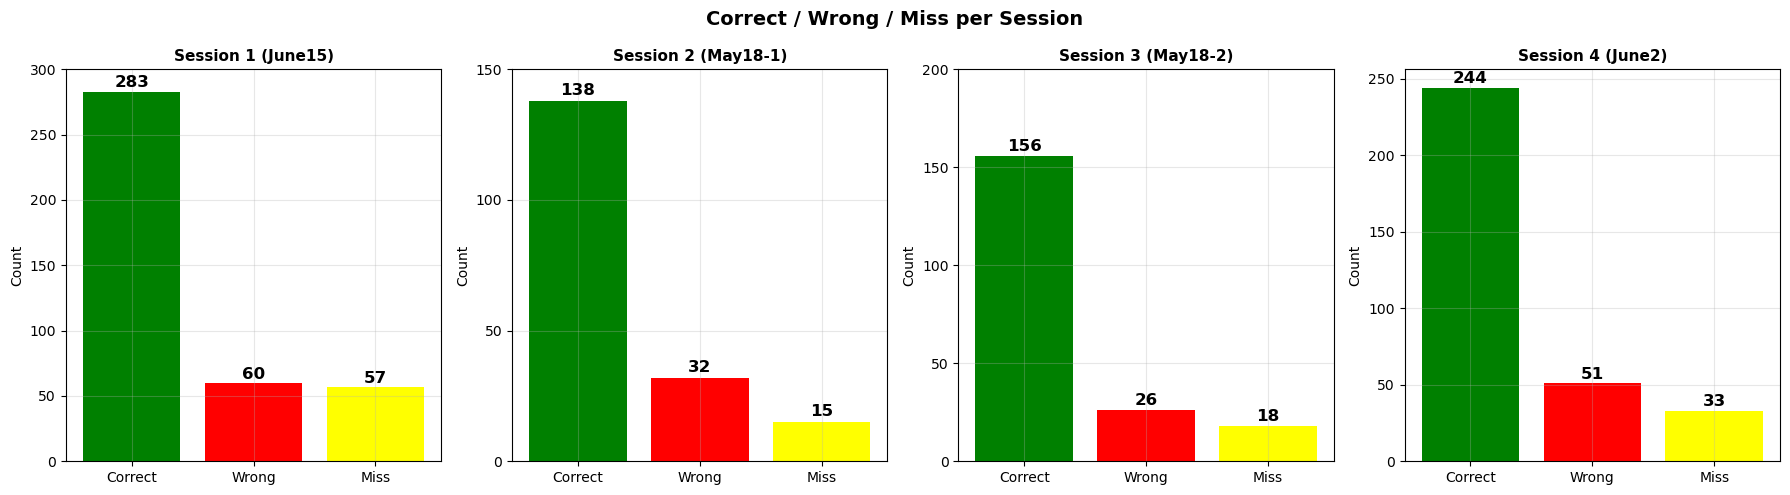

            Session  Total  Correct  Wrong  Miss Correct % Wrong % Miss %
 Session 1 (June15)    400      283     60    57     70.8%   15.0%  14.2%
Session 2 (May18-1)    185      138     32    15     74.6%   17.3%   8.1%
Session 3 (May18-2)    200      156     26    18     78.0%   13.0%   9.0%
  Session 4 (June2)    328      244     51    33     74.4%   15.5%  10.1%


In [18]:
# %%
# ── Bar graph: Correct / Wrong / Miss per session ──────────────
evt_hit   = 1
evt_wrong = 2
evt_miss  = list(range(113, 118))

fig, axes = plt.subplots(1, len(sessions), figsize=(18, 5), sharey=False)

summary_rows = []

for ax, (name, data) in zip(axes, sessions.items()):
    events = data["Event"]
    correct_count = np.sum([evt_hit   in ev for ev in events])
    wrong_count   = np.sum([evt_wrong in ev for ev in events])
    error_count   = np.sum([any(e in evt_miss for e in ev) for ev in events])

    counts = [correct_count, wrong_count, error_count]
    labels = ["Correct", "Wrong", "Miss"]
    colors = ["green", "red", "yellow"]

    bars = ax.bar(labels, counts, color=colors)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_ylabel("Count")
    ax.set_yticks(np.arange(0, max(counts) + 51, 50))
    ax.grid(True, alpha=0.3)

    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

    total = len(data)
    summary_rows.append({
        "Session"  : name,
        "Total"    : total,
        "Correct"  : correct_count,
        "Wrong"    : wrong_count,
        "Miss"     : error_count,
        "Correct %": f"{correct_count/total*100:.1f}%",
        "Wrong %"  : f"{wrong_count/total*100:.1f}%",
        "Miss %"   : f"{error_count/total*100:.1f}%",
    })

plt.suptitle("Correct / Wrong / Miss per Session", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../figures/bar_all_sessions.png", dpi=150, bbox_inches='tight')
plt.show()

# print summary table
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

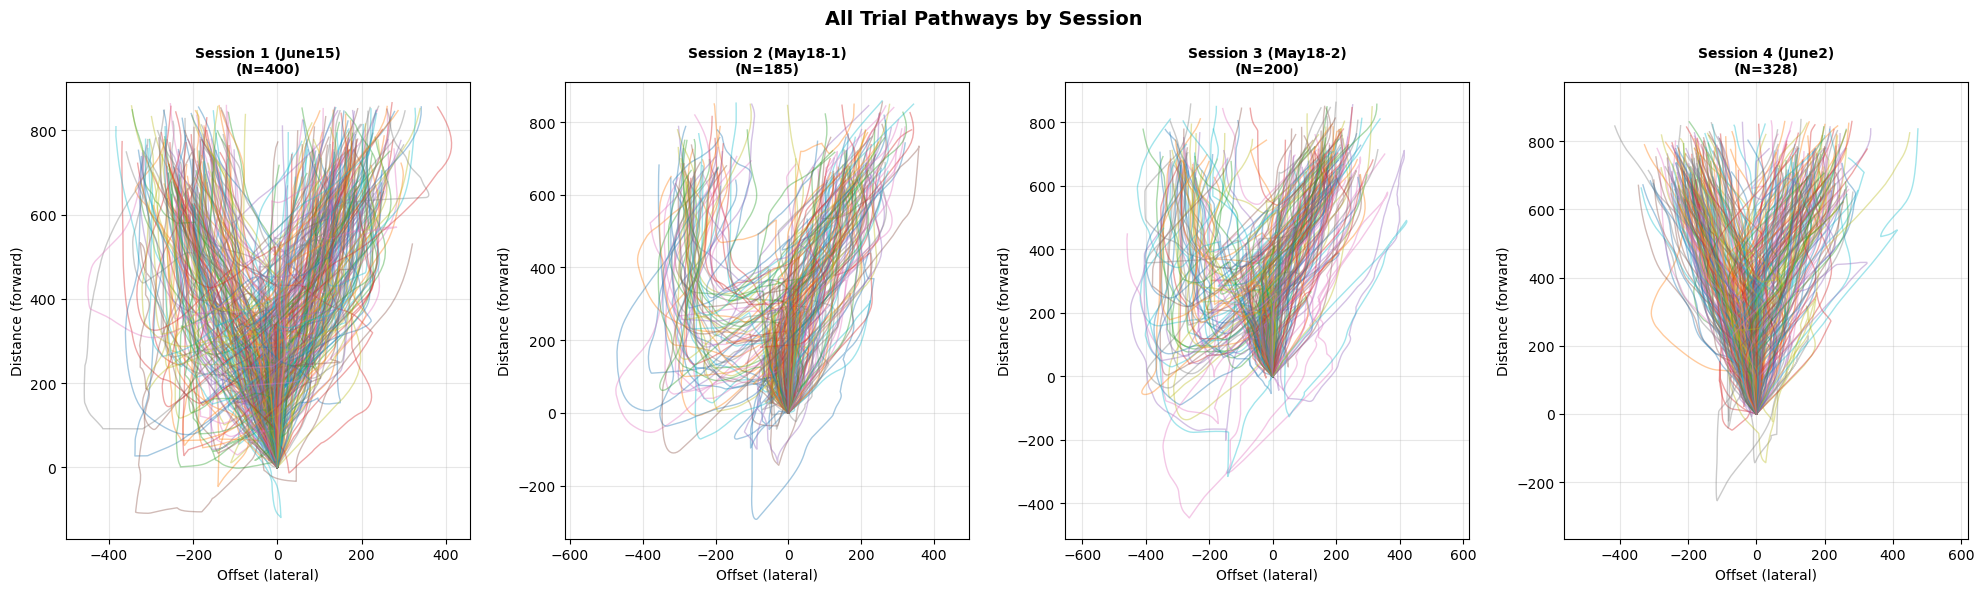

In [19]:
# %%
# ── All trial pathways per session ────────────────────────────
fig, axes = plt.subplots(1, len(sessions), figsize=(20, 6))

for ax, (name, data) in zip(axes, sessions.items()):
    paths = data["Location"]
    n = len(paths)
    for i in range(n):
        path = paths[i]
        ax.plot(path[:, 1], path[:, 0], '-', linewidth=1.0, alpha=0.4)
    ax.set_title(f"{name}\n(N={n})", fontsize=10, fontweight='bold')
    ax.set_xlabel("Offset (lateral)")
    ax.set_ylabel("Distance (forward)")
    ax.axis('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle("All Trial Pathways by Session", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../figures/pathways_all_sessions.png", dpi=150, bbox_inches='tight')
plt.show()


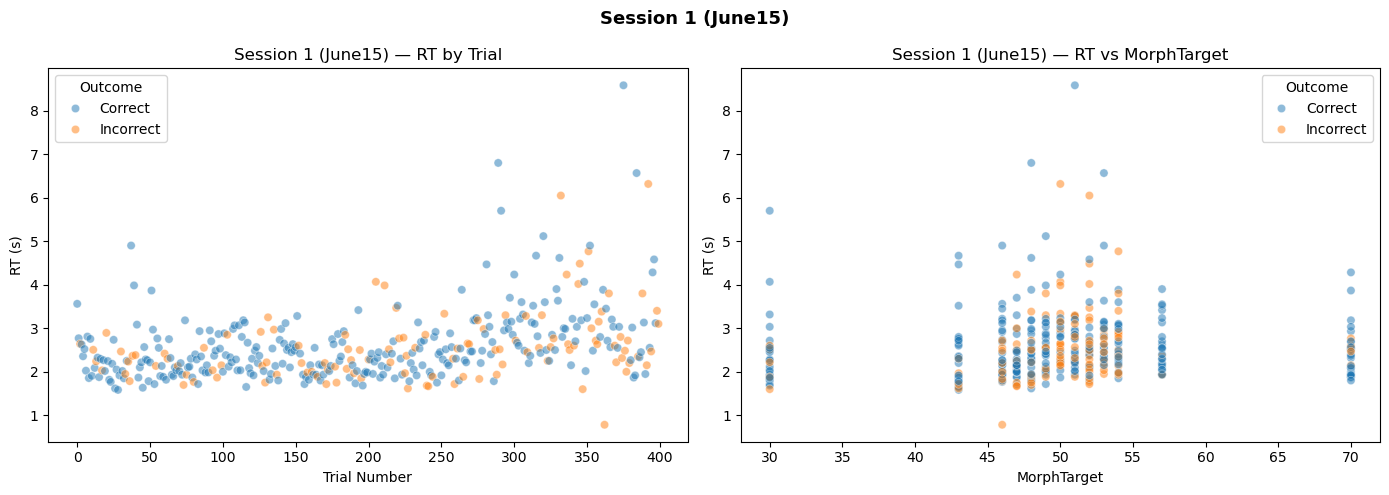

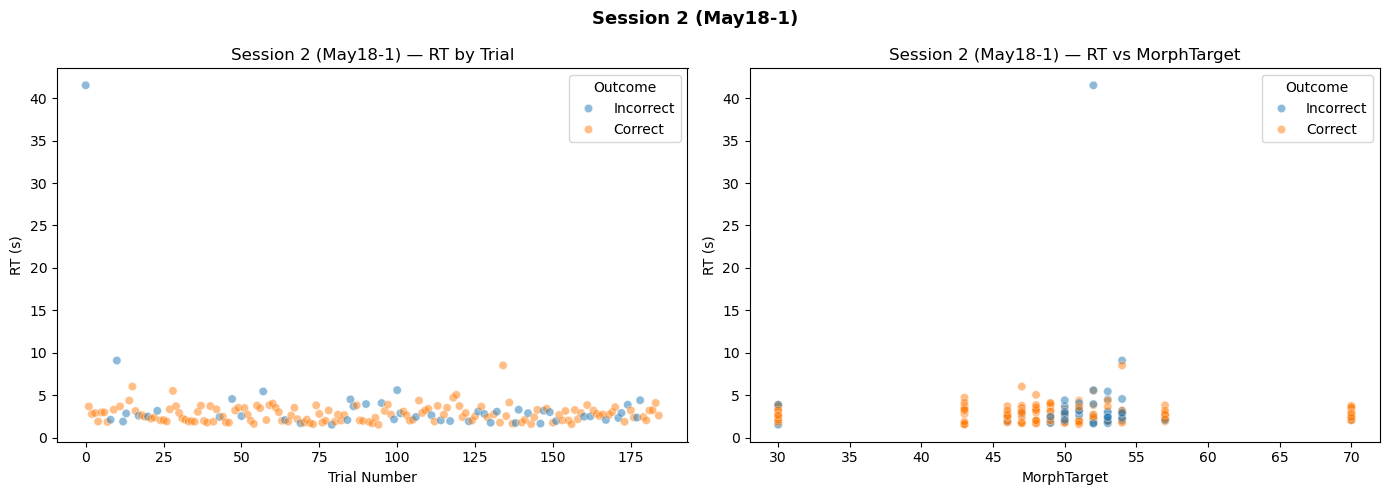

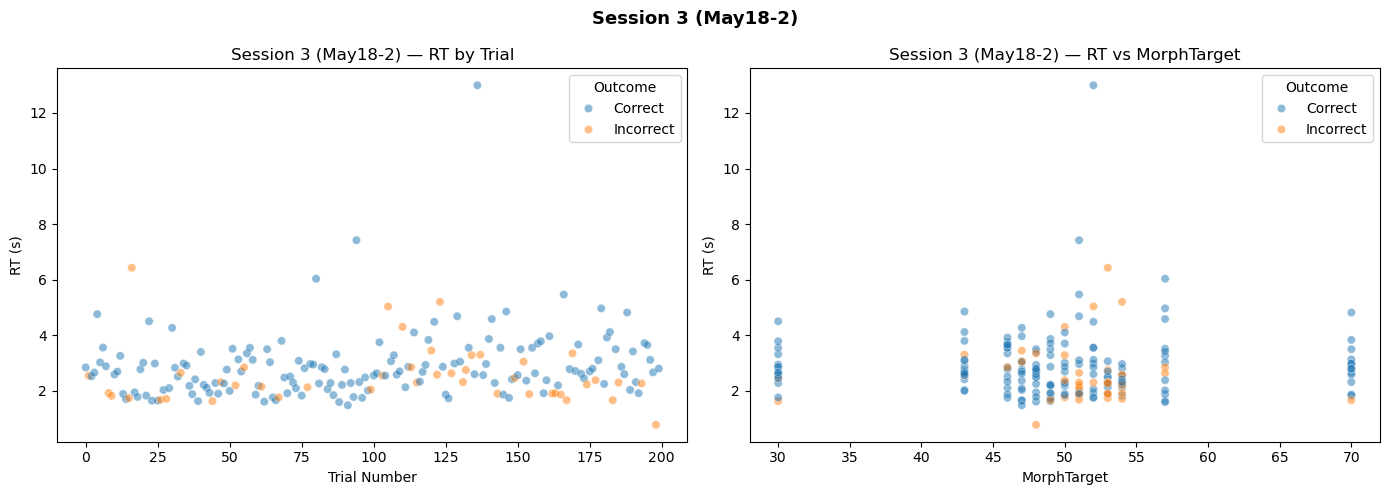

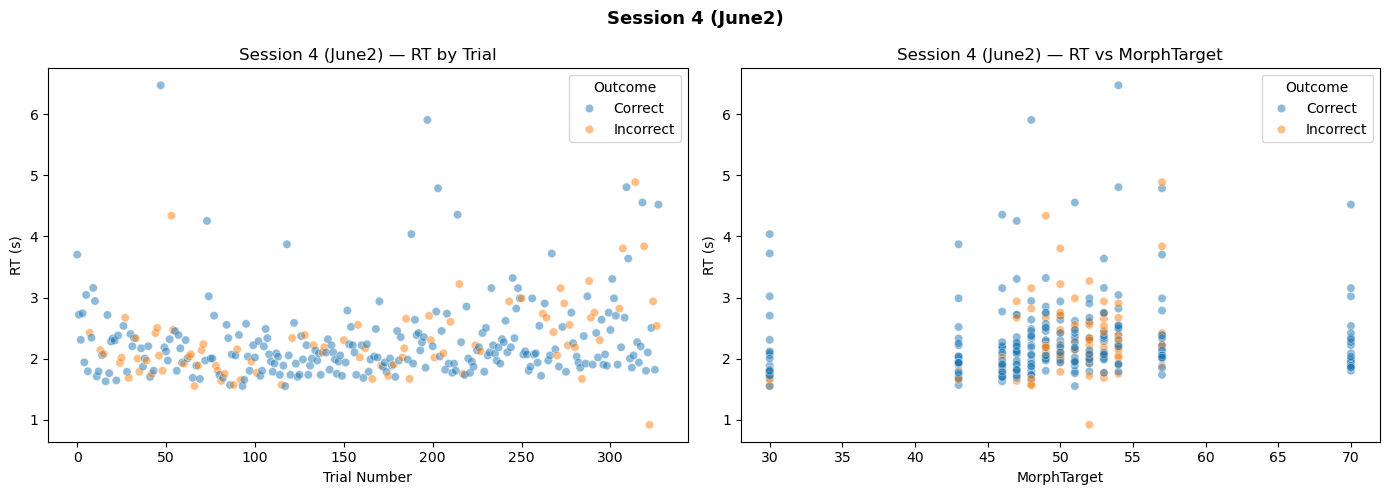

In [20]:
# %%
# ── RT and accuracy plots ──────────────────────────────────────
for name, data in sessions.items():
    df = data.copy()

    # RT
    if "RT" not in df.columns:
        df["RT"] = df["EndTs"] - df["FlashTs"]

    # outcome
    df["Outcome"] = np.where(df["Correct"] == 1, "Correct", "Incorrect")

    # difficulty column
    for cand in ["MorphTarget", "Offset", "Distance", "BaseConditionTarget"]:
        if cand in df.columns:
            diff_col = cand
            break

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # RT vs trial index
    sns.scatterplot(data=df, x="TrialIndex", y="RT",
                    hue="Outcome", alpha=0.5, ax=axes[0])
    axes[0].set_title(f"{name} — RT by Trial")
    axes[0].set_xlabel("Trial Number")
    axes[0].set_ylabel("RT (s)")

    # RT vs difficulty
    sns.scatterplot(data=df, x=diff_col, y="RT",
                    hue="Outcome", alpha=0.5, ax=axes[1])
    axes[1].set_title(f"{name} — RT vs {diff_col}")
    axes[1].set_xlabel(diff_col)
    axes[1].set_ylabel("RT (s)")

    plt.suptitle(name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"../figures/rt_{name.replace(' ', '_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()